<a href="https://colab.research.google.com/github/kakade24/ees322_remote_sensing_lab/blob/main/spectral_indices_from_landsat_8_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# geemap provides convenient interactive Earth Engine maps in notebooks.
%pip -q install -U geemap

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Packages imported successfully.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.5 MB/s eta 0:00:00
Packages imported successfully.


In [3]:
# Authenticate and initialise Earth Engine.
# Replace this with the Google Cloud Project ID assigned for the practical.
PROJECT_ID = 'plllssskms'

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print('Earth Engine initialised.')


Earth Engine initialised.


In [4]:
# Example centre point near Nagpur, Maharashtra.
CENTER_LON = 79.0849
CENTER_LAT = 21.1463

centre = ee.Geometry.Point([CENTER_LON, CENTER_LAT])
aoi = centre.buffer(20_000).bounds()  # 20 km buffer, converted to a bounding rectangle
sample_point = centre

print('AOI created.')

AOI created.


In [5]:
START_DATE = '2025-01-01'
END_DATE   = '2025-12-31'
MAX_CLOUD  = 60  # scene-level cloud cover percentage

raw_collection = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt('CLOUD_COVER', MAX_CLOUD))
)

scene_count = raw_collection.size().getInfo()
print('Number of matching scenes:', scene_count)

if scene_count == 0:
    raise ValueError('No scenes found. Increase the date range or MAX_CLOUD.')


Number of matching scenes: 36


In [6]:
def preprocess_landsat8(image):
    qa = image.select("QA_PIXEL")

    # QA_PIXEL:
    # bit 1 = dilated cloud
    # bit 2 = cirrus
    # bit 3 = cloud
    # bit 4 = cloud shadow
    # bit 5 = snow
    clear_mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
        .And(qa.bitwiseAnd(1 << 5).eq(0))
    )

    saturation_mask = image.select("QA_RADSAT").eq(0)

    optical = (
        image.select("SR_B[1-7]")
        .multiply(0.0000275)
        .add(-0.2)
    )

    return (
        image.addBands(optical, None, True)
        .updateMask(clear_mask)
        .updateMask(saturation_mask)
    )

image = ee.Image(raw_collection.sort("CLOUD_COVER").first())
image = preprocess_landsat8(image)

print("Product ID:", image.get("LANDSAT_PRODUCT_ID").getInfo())
print("Acquisition date:", image.date().format("YYYY-MM-dd").getInfo())
print("Scene cloud cover %:", image.get("CLOUD_COVER").getInfo())

Product ID: LC08_L2SP_144045_20250108_20250121_02_T1
Acquisition date: 2025-01-08
Scene cloud cover %: 0


In [12]:
# Select the reflectance bands once for clarity.
green = image.select("SR_B3")
red = image.select("SR_B4")
nir = image.select("SR_B5")
swir2 = image.select("SR_B7")

# NDVI
ndvi = image.expression(
    "(NIR - RED) / (NIR + RED)",
    {"NIR": nir, "RED": red}
).rename("NDVI")

# McFeeters NDWI
ndwi = image.expression(
    "(GREEN - NIR) / (GREEN + NIR)",
    {"GREEN": green, "NIR": nir}
).rename("NDWI")

# SAVI
L = 0.5
savi = image.expression(
    "((NIR - RED) / (NIR + RED + L)) * (1 + L)",
    {"NIR": nir, "RED": red, "L": L}
).rename("SAVI")

# NBR
nbr = image.expression(
    "(NIR - SWIR2) / (NIR + SWIR2)",
    {"NIR": nir, "SWIR2": swir2}
).rename("NBR")

index_image = image.addBands([ndvi, ndwi, savi, nbr])

print("Index bands added:")
print(index_image.bandNames().getInfo())

Index bands added:
['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI', 'NDWI', 'SAVI', 'NBR']


In [13]:
Map = geemap.Map()
Map.centerObject(aoi, 10)


true_color = {
    "bands": ["SR_B4", "SR_B3", "SR_B2"],
    "min": 0.0,
    "max": 0.30,
}

false_color = {
    "bands": ["SR_B5", "SR_B4", "SR_B3"],
    "min": 0.0,
    "max": 0.35,
}

Map.addLayer(image.clip(aoi),true_color,"True Color (4-3-2)",True)
Map.addLayer(image.clip(aoi),false_color,"False Color (5-4-3)",False)

Map.addLayer(
    ndvi.clip(aoi),
    {"min": -1,"max": 1,"palette": ["8c510a", "f6e8c3", "01665e"] },
    "NDVI",
    False
)

Map.addLayer(
    ndwi.clip(aoi),
    {
        "min": -1,
        "max": 1,
        "palette": ["a6611a", "f5f5f5", "018571"]
    },
    "NDWI (McFeeters)",
    False
)

Map.addLayer(
    savi.clip(aoi),
    {
        "min": -1,
        "max": 1,
        "palette": ["8c510a", "f6e8c3", "01665e"]
    },
    "SAVI",
    False
)

Map.addLayer(
    nbr.clip(aoi),
    {
        "min": -1,
        "max": 1,
        "palette": ["b2182b", "f7f7f7", "2166ac"]
    },
    "NBR",
    False
)

Map.addLayer(aoi, {"color": "black"}, "AOI", False)

Map

Map(center=[21.146297645180788, 79.08523023042375], controls=(WidgetControl(options=['position', 'transparent_…

In [14]:
indices = index_image.select(["NDVI", "NDWI", "SAVI", "NBR"])

stats = indices.reduceRegion(
    reducer=(
        ee.Reducer.mean()
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
        .combine(ee.Reducer.minMax(), sharedInputs=True)
    ),
    geometry=aoi,
    scale=30,
    maxPixels=1e8,
    bestEffort=True,
)

stats_dict = stats.getInfo()

summary_rows = []
for name in ["NDVI", "NDWI", "SAVI", "NBR"]:
    summary_rows.append({
        "Index": name,
        "Mean": stats_dict.get(f"{name}_mean"),
        "StdDev": stats_dict.get(f"{name}_stdDev"),
        "Min": stats_dict.get(f"{name}_min"),
        "Max": stats_dict.get(f"{name}_max"),
    })
summary_df= pd.DataFrame(summary_rows)
summary_df

,Index,Mean,StdDev,Min,Max
0,NDVI,0.435802,0.491117,-608.208333,15.734950
1,NDWI,-0.465554,0.160394,-66.258389,56.005076
2,SAVI,0.238409,0.095447,-0.230309,1.028658
3,NBR,0.239656,0.168123,-1.001395,1.449950


In [16]:
sample_fc = indices.sample(
    region=aoi,
    scale=30,
    numPixels=2500,
    seed=42,
    geometries=False,
    tileScale=2,
)

sample_info = sample_fc.getInfo()

sample_df = pd.DataFrame(
    [feature["properties"] for feature in sample_info["features"]]
).dropna()

print("Number of sampled clear pixels:", len(sample_df))
sample_df.head()

Number of sampled clear pixels: 2495


,NBR,NDVI,NDWI,SAVI
0,0.404994,0.586892,-0.568287,0.326250
1,-0.004428,0.202808,-0.252452,0.094750
2,0.037965,0.330702,-0.410557,0.172547
3,0.184007,0.383115,-0.450153,0.189646
4,0.065937,0.294492,-0.390876,0.162469


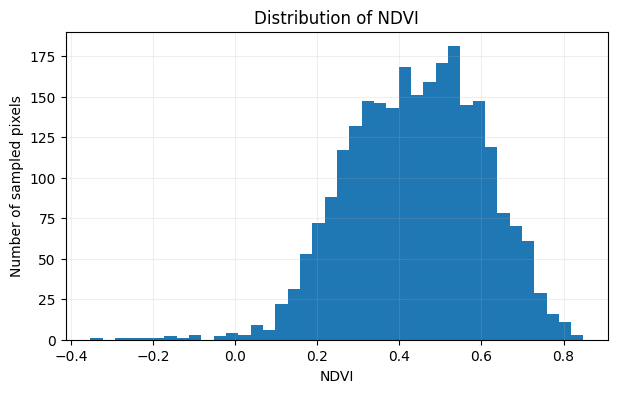

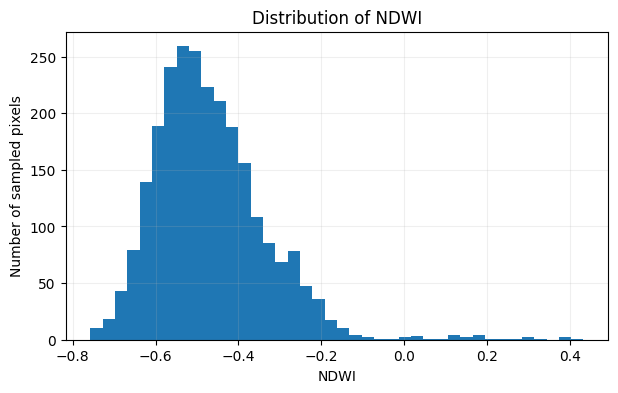

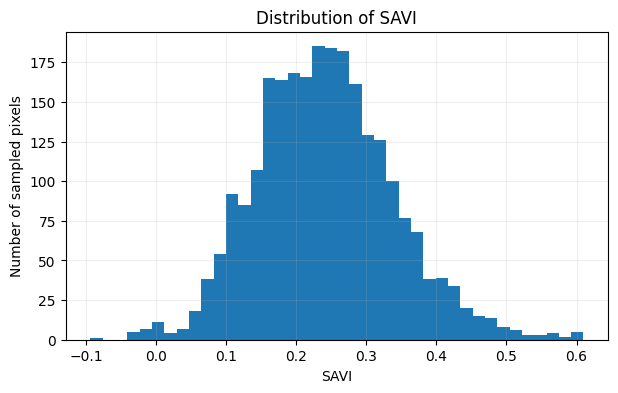

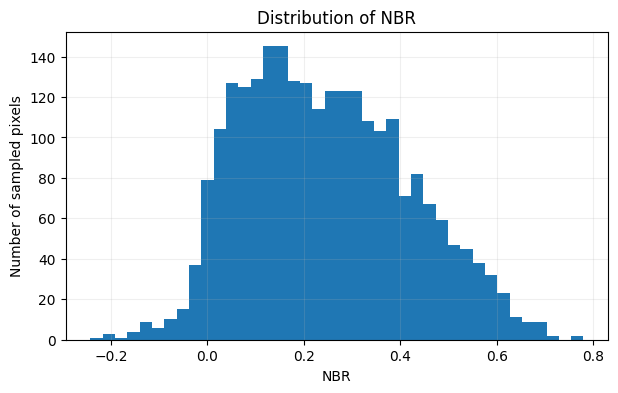

In [18]:
# Plot a separate histogram for each index.
for name in ["NDVI", "NDWI", "SAVI", "NBR"]:
    plt.figure(figsize=(7, 4))
    plt.hist(sample_df[name], bins=40)
    plt.xlabel(name)
    plt.ylabel("Number of sampled pixels")
    plt.title(f"Distribution of {name}")
    plt.grid(alpha=0.2)
    plt.show()

In [19]:
# Compare NDVI and SAVI numerically.
sample_df["NDVI_minus_SAVI"] = sample_df["NDVI"] - sample_df["SAVI"]

comparison = sample_df[["NDVI", "SAVI", "NDVI_minus_SAVI"]].describe()
comparison

,NDVI,SAVI,NDVI_minus_SAVI
count,2495.000000,2495.000000,2495.000000
mean,0.440135,0.241323,0.198813
std,0.162496,0.097540,0.073042
min,-0.353615,-0.093731,-0.259884
25%,0.323229,0.173541,0.145819
50%,0.443907,0.237643,0.208415
75%,0.561742,0.301441,0.254491
max,0.848684,0.609852,0.394121


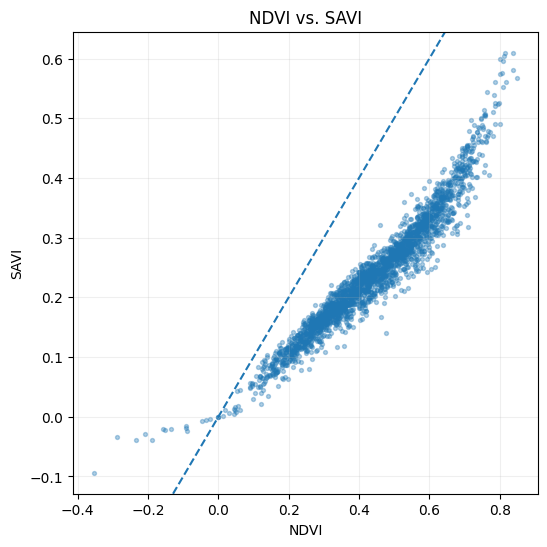

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(sample_df["NDVI"], sample_df["SAVI"], s=8, alpha=0.35)
plt.xlabel("NDVI")
plt.ylabel("SAVI")
plt.title("NDVI vs. SAVI")
plt.axline((0,0),slope=1,linestyle="--")
plt.grid(alpha=0.2)
plt.show()

In [21]:
vegetation_candidate = ndvi.gt(0.40).rename("Vegetation_candidate")
water_candidate = ndwi.gt(0.00).rename("Water_candidate")

MaskMap = geemap.Map()
MaskMap.centerObject(aoi, 10)
MaskMap.addLayer(image.clip(aoi), true_color, "True colour", True)
MaskMap.addLayer(
    vegetation_candidate.selfMask().clip(aoi),
    {"palette": ["00AA00"]},
    "NDVI > 0.40",
    False,
)
MaskMap.addLayer(
    water_candidate.selfMask().clip(aoi),
    {"palette": ["0000FF"]},
    "NDWI > 0",
    False,
)
MaskMap

Map(center=[21.146297645180788, 79.08523023042375], controls=(WidgetControl(options=['position', 'transparent_…

In [22]:
export_indices = index_image.select(
    ["NDVI", "NDWI", "SAVI", "NBR"]
).clip(aoi)

task = ee.batch.Export.image.toDrive(
    image=export_indices,
    description="Landsat8_Spectral_Indices",
    folder="EarthEngine",
    fileNamePrefix="Landsat8_NDVI_NDWI_SAVI_NBR",
    region=aoi,
    scale=30,
    maxPixels=1e9,
    fileFormat="GeoTIFF",
)

# task.start()

print("Export prepared. Uncomment task.start() to submit it.")

Export prepared. Uncomment task.start() to submit it.
